In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf

df = pd.read_csv('../data/berek_update.csv')
print(f'Shape: {df.shape}')

print(df.columns.tolist())

Shape: (177421, 25)
['sex', 'contract_type', 'fulltime', 'earnings', 'nuts2_region', 'settlement_type', 'any_supplement', 'firm_size_v1', 'collective_agreement', 'union_presence', 'age', 'tenure_years', 'new_hire', 'education_5cat', 'experience', 'experience_sq', 'overtime_dummy', 'log_earnings', 'firm_size_4cat', 'foreign_majority', 'state_majority', 'industry_13cat', 'position_5cat', 'total_hours', 'log_tenure']


### 1. Multicollinearity Assessment

#### VIF - Continuous Predictors

In [2]:
# Check VIF
numeric_cols = ['experience', 
                'log_tenure', 'age', 'total_hours']

vif_data = pd.DataFrame()
vif_data['Variable'] = numeric_cols
vif_data['VIF'] = [variance_inflation_factor(df[numeric_cols].dropna().values, i) 
                   for i in range(len(numeric_cols))]

print(vif_data.sort_values('VIF', ascending=False).to_string())

      Variable         VIF
2          age  147.875545
0   experience   60.792078
3  total_hours   28.540200
1   log_tenure    4.680243


Initial VIF calculation reveals that `age` is severely collinear with the other predictors (VIF = 147), which is expected since age ≈ experience + schooling + 6 years We therefore exclude `age` from the model and rely on `experience` to capture the lifecycle earnings profile.

In [3]:
# Recheck VIF
numeric_cols = ['experience', 
                'log_tenure', 'total_hours']

vif_data = pd.DataFrame()
vif_data['Variable'] = numeric_cols
vif_data['VIF'] = [variance_inflation_factor(df[numeric_cols].dropna().values, i) 
                   for i in range(len(numeric_cols))]

print(vif_data.sort_values('VIF', ascending=False).to_string())

      Variable       VIF
2  total_hours  5.868934
0   experience  4.981090
1   log_tenure  4.604583


After dropping `age`, all VIF values fall well within acceptable bounds (max 5.87). Note that including `experience_sq` alongside `experience` will introduce some inherent correlation between the two terms by construction. This is expected and does not constitute problematic multicollinearity, as it reflects the intended polynomial specification rather than redundant information.

#### Cramér's V - Categorical Variable Associations

Pearson correlation is not defined for categorical variables. We therefore compute Cramér's V for all pairwise combinations of categorical predictors: a chi-squared based measure of association bounded between 0 and 1, making it the natural analogue of correlation for nominal variables. No pair exceeds 0.47, and the vast majority of associations are below 0.15, indicating that multicollinearity among categorical predictors is not a concern.

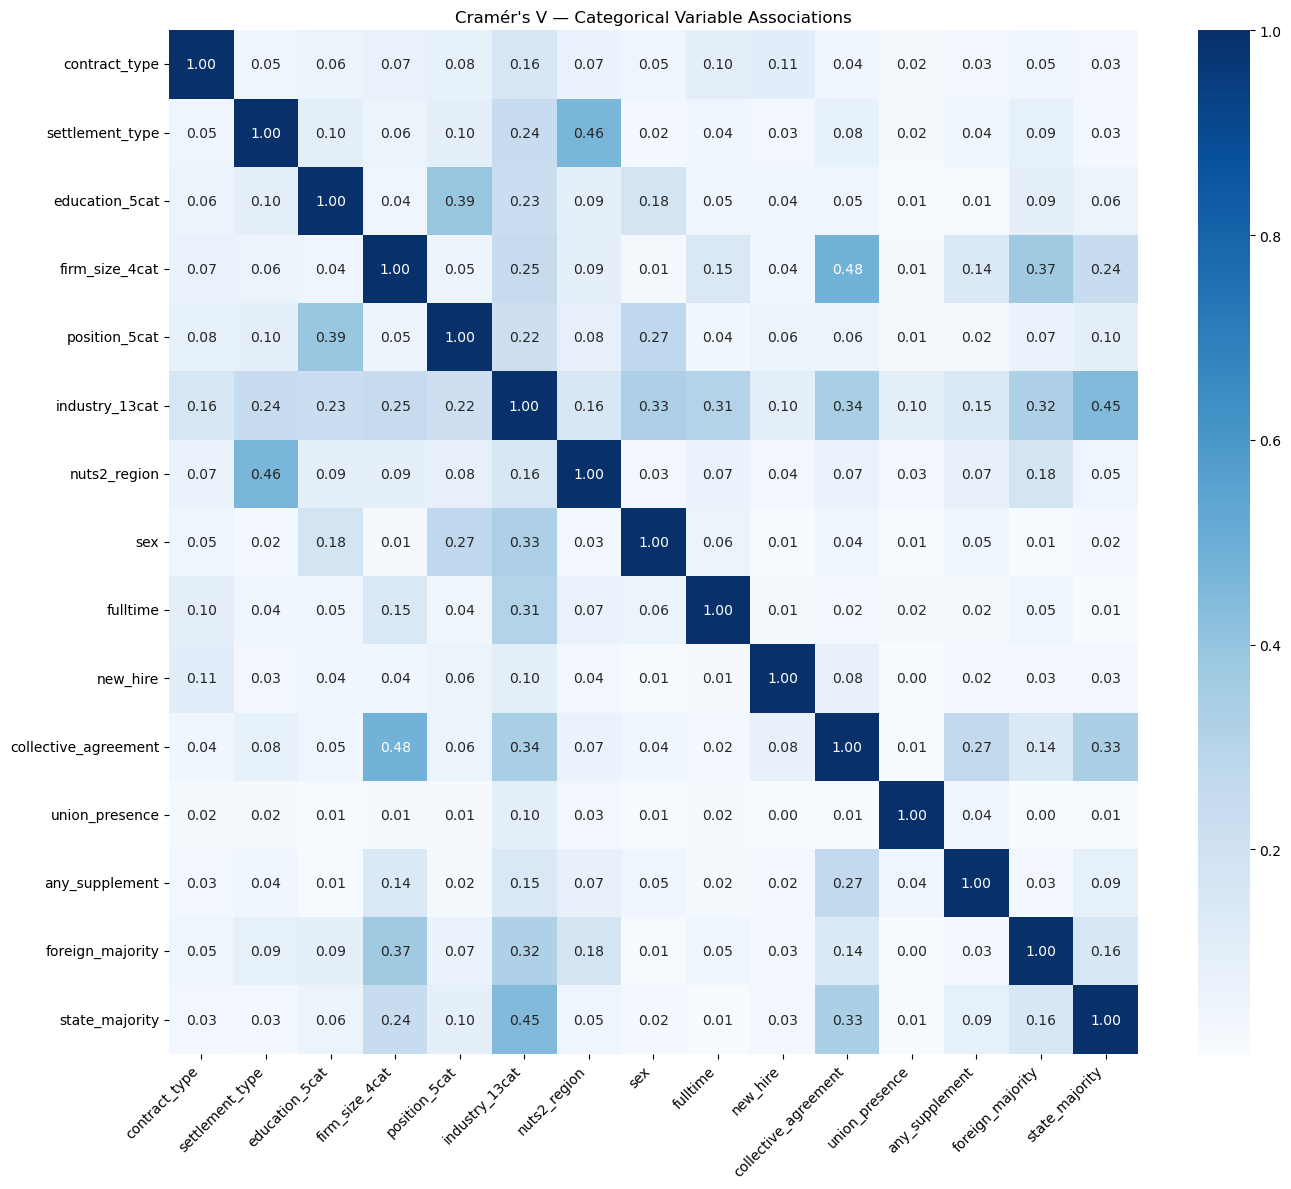

In [4]:
from scipy.stats import chi2_contingency
import itertools

cat_cols = ['contract_type', 'settlement_type', 'education_5cat', 'firm_size_4cat',
            'position_5cat', 'industry_13cat', 'nuts2_region', 'sex', 'fulltime',
            'new_hire', 'collective_agreement', 'union_presence', 'any_supplement',
            'foreign_majority', 'state_majority']

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(r-1, k-1))

# Compute Cramer's V for all pairs
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1, col2 in itertools.combinations(cat_cols, 2):
    v = cramers_v(df[col1].dropna(), df[col2].dropna())
    cramers_matrix.loc[col1, col2] = v
    cramers_matrix.loc[col2, col1] = v

for col in cat_cols:
    cramers_matrix.loc[col, col] = 1.0

# Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt='.2f', cmap='Blues',
            xticklabels=cat_cols, yticklabels=cat_cols)
plt.title("Cramér's V — Categorical Variable Associations")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../figs/VIF_cramers.png", dpi=300, bbox_inches='tight')
plt.show()

#### Eta-Squared - Categorical × Continuous Associations

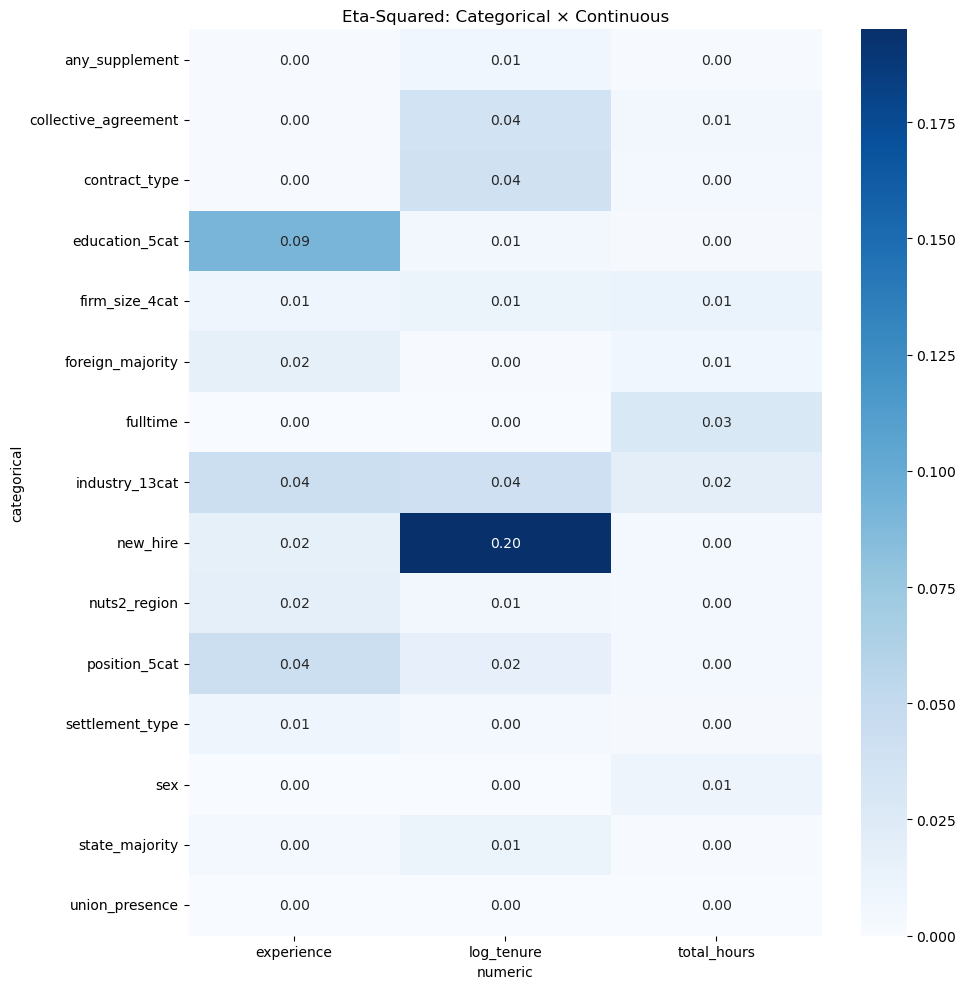

In [5]:
from scipy.stats import f_oneway

cat_cols = ['contract_type', 'settlement_type', 'education_5cat', 'firm_size_4cat',
            'position_5cat', 'industry_13cat', 'nuts2_region', 'sex', 'fulltime',
            'new_hire', 'collective_agreement', 'union_presence', 'any_supplement',
            'foreign_majority', 'state_majority']

numeric_cols = ['experience', 'log_tenure', 'total_hours']

def eta_squared(cat, num):
    groups = [num[cat == c].dropna() for c in cat.dropna().unique()]
    grand_mean = num.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((num - grand_mean)**2)
    return ss_between / ss_total

results = []
for c in cat_cols:
    for n in numeric_cols:
        eta2 = eta_squared(df[c], df[n].dropna())
        results.append({'categorical': c, 'numeric': n, 'eta_squared': round(eta2, 3)})

eta_df = pd.DataFrame(results).pivot(index='categorical', columns='numeric', values='eta_squared')

plt.figure(figsize=(10, 10))
sns.heatmap(eta_df, annot=True, fmt='.2f', cmap='Blues')
plt.title('Eta-Squared: Categorical × Continuous')
plt.tight_layout()
plt.savefig("../figs/VIF_eta_squared.png", dpi=300, bbox_inches='tight')
plt.show()

To assess associations between categorical and continuous predictors, we compute eta-squared (η²), which measures the proportion of variance in a continuous variable explained by the groupings of a categorical variable, the natural analogue of R² for this type of association. The highest values are `new_hire` × `log_tenure` (0.2) and `education_5cat` × `general_experience` (0.09), both of which are economically intuitive rather than indicative of harmful collinearity. All other pairs are below 0.07, confirming that categorical and continuous predictors carry largely independent information.

### Model Specification

We estimate two OLS models. The baseline model includes all main effects without interactions. `union_presence` is excluded from the second model as it was not significant in the baseline (p = 0.99). The interaction model adds ownership × worker characteristic interactions motivated by the EDA, where foreign-majority firms showed visually distinct slopes for experience, tenure, total hours, education, and position.

In [6]:
import statsmodels.formula.api as smf

baseline_formula = """
log_earnings ~ foreign_majority + state_majority
             + experience + experience_sq + log_tenure
             + total_hours + sex + education_5cat + position_5cat
             + contract_type + fulltime + any_supplement
             + firm_size_4cat + collective_agreement + union_presence
             + industry_13cat + settlement_type + nuts2_region
"""

baseline_model = smf.ols(baseline_formula, data=df).fit()
print(baseline_model.summary2())

                           Results: Ordinary least squares
Model:                    OLS                    Adj. R-squared:           0.556      
Dependent Variable:       log_earnings           AIC:                      166731.0988
Date:                     2026-05-13 20:05       BIC:                      167184.9814
No. Observations:         177421                 Log-Likelihood:           -83321.    
Df Model:                 44                     F-statistic:              5046.      
Df Residuals:             177376                 Prob (F-statistic):       0.00       
R-squared:                0.556                  Scale:                    0.14981    
--------------------------------------------------------------------------------------
                                       Coef.  Std.Err.    t     P>|t|   [0.025  0.975]
--------------------------------------------------------------------------------------
Intercept                             11.5560   0.0358 322.9446 0.0000 

**Key coefficients: baseline model:**
- `foreign_majority`: +0.22 (~25% wage premium)
- `state_majority`: +0.02 (~2% premium, modest but significant)
- `sex[male]`: +0.14 (~15% gender gap)
- `education[tertiary]`: +0.56 (~75% premium over no/incomplete primary)
- `position[manual]`: -0.52 relative to top management

In [7]:
interaction_formula = """
log_earnings ~ foreign_majority + state_majority
             + experience + experience_sq + log_tenure
             + total_hours + sex + education_5cat + position_5cat
             + contract_type + fulltime + any_supplement
             + firm_size_4cat + collective_agreement
             + industry_13cat + settlement_type + nuts2_region
             + foreign_majority:experience
             + foreign_majority:total_hours
             + foreign_majority:log_tenure
             + foreign_majority:education_5cat
             + foreign_majority:position_5cat
"""

interaction_model = smf.ols(interaction_formula, data=df).fit()
print(f'R-squared: {interaction_model.rsquared:.4f}')
print(f'Adj. R-squared: {interaction_model.rsquared_adj:.4f}')
print(f'N observations: {int(interaction_model.nobs)}')
print(f'AIC: {interaction_model.aic:.2f}')
print(f'BIC: {interaction_model.bic:.2f}')
print(interaction_model.summary2())

R-squared: 0.5699
Adj. R-squared: 0.5698
N observations: 177421
AIC: 161040.15
BIC: 161594.89
                                    Results: Ordinary least squares
Model:                          OLS                          Adj. R-squared:                 0.570      
Dependent Variable:             log_earnings                 AIC:                            161040.1450
Date:                           2026-05-13 20:06             BIC:                            161594.8905
No. Observations:               177421                       Log-Likelihood:                 -80465.    
Df Model:                       54                           F-statistic:                    4353.      
Df Residuals:                   177366                       Prob (F-statistic):             0.00       
R-squared:                      0.570                        Scale:                          0.14507    
-------------------------------------------------------------------------------------------------------

**Key coefficients - interaction model:**
- `foreign_majority` main effect rises to +0.43, now interpreted as the premium
  for top management specifically (baseline worker)
- `foreign_majority × experience`: +0.001 -> slightly higher returns to experience
  at foreign firms
- `foreign_majority × log_tenure`: +0.017 -> higher tenure premium at foreign firms
- `foreign_majority × education[tertiary]`: +0.30 -> foreign firms disproportionately
  reward tertiary-educated workers; lower education interactions insignificant
- `foreign_majority × position[manual]`: -0.74 -> foreign premium reverses for manual
  workers (net effect: -0.31), concentrated entirely at the top of the job hierarchy

**Observations:**

The `foreign_majority` main effect jumps to +0.43, but this now reflects the premium for the baseline worker (top management, no completed primary education, zero experience/tenure/hours), not the average worker. The substantive results are in the interactions.

**Position interactions dominate.** The foreign premium is concentrated at the top of the job hierarchy and reverses further down:

| Position       | Net foreign premium         |
|----------------|-----------------------------|
| Top management | +0.43 (base)                |
| Management     | +0.43 - 0.34 = +0.09        |
| Professional   | +0.43 - 0.63 = **-0.20**   |
| Clerical       | +0.43 - 0.66 = **-0.23**   |
| Manual         | +0.43 - 0.74 = **-0.31**   |

Foreign firms pay a substantial premium to top management but pay **less** than domestic private firms to professional, clerical, and manual workers, conditional on observables. This is the central finding of the interaction model.

**Education interactions are weak.** Only the tertiary interaction is significant (coef = +0.30, p = 0.01); all lower education categories are insignificant. Foreign firms disproportionately reward tertiary education, but education is otherwise not a major dimension of heterogeneity in the ownership premium.

**Human capital interactions are positive but modest.** `foreign_majority × log_tenure` (+0.017) and `foreign_majority × experience` (+0.001) are both significant, foreign firms reward tenure and experience somewhat more than domestic firms. `foreign_majority × total_hours` (+0.001) is significant but economically negligible.

**Condition number concern.** The condition number rises sharply from ~82k to ~246k, likely driven by thin cell counts in the `foreign_majority × education` interactions (foreign-majority firms are rare in some education cells). 

The education interaction coefficients should be interpreted cautiously: sparse cells (few foreign-majority observations in lower education categories) inflate standard errors and likely drive the elevated condition number, though this does not affect the position or human capital interactions, nor the substantive conclusions given that those coefficients are insignificant regardless.

In [8]:
print(f'Baseline - AIC: {baseline_model.aic:.0f}, BIC: {baseline_model.bic:.0f}')
print(f'Interaction - AIC: {interaction_model.aic:.0f}, BIC: {interaction_model.bic:.0f}')

Baseline - AIC: 166731, BIC: 167185
Interaction - AIC: 161040, BIC: 161595


Both information criteria favor the interaction model: AIC drops from 166,731 to 161,040 and BIC from 167,185 to 161,595, a reduction of ~5,700 units in both cases. This is decisive by any conventional threshold and confirms that the interaction terms jointly improve fit enough to justify the additional 10 parameters. That said, model selection here is not really the point. The interactions are motivated by the research question, we are not asking whether a parsimonious baseline fits the data, but whether the foreign ownership premium varies systematically across worker characteristics. The AIC/BIC comparison simply confirms that this heterogeneity is real and not overfitting.

### Regularization Methods

We chose not to employ regularization methods in this analysis. Lasso, ridge, and elastic net are designed to minimize out-of-sample prediction error by shrinking coefficients toward zero, a goal that is orthogonal to ours. Our objective is inference on the ownership wage premium and its heterogeneity across worker characteristics, which requires unbiased, interpretable OLS estimates rather than shrinkage estimators optimized for predictive accuracy.

Lasso is particularly ill-suited here: by zeroing out correlated predictors arbitrarily, it would undermine the identification of the ownership coefficients rather than improve it. Industry, region, and position controls are retained on economic grounds, not because they maximize predictive fit. Ridge regression could in principle serve as a robustness check on the elevated condition number in the interaction model. If OLS and ridge estimates are close, that would confirm that collinearity is not materially distorting our estimates. We did not pursue this given that the condition number concern is localized to the `foreign_majority × education` interactions, which are largely insignificant regardless and do not affect the substantive conclusions.

### Heteroscedasticity Test and Model Choice

The Breusch-Pagan returns p-value of 0.000, rejecting the null hypothesis of homoscedastic errors.

In [9]:
import statsmodels.stats.diagnostic as diag

# Breusch-Pagan test for heteroscedasticity
bp_test = diag.het_breuschpagan(interaction_model.resid, interaction_model.model.exog)

print(f'Breusch-Pagan test:')
print(f'LM statistic: {bp_test[0]:.4f}')
print(f'p-value:      {bp_test[1]:.4f}')


Breusch-Pagan test:
LM statistic: 22822.6016
p-value:      0.0000


So we will go by the heteroscedastic linear model (HLM) with Eicker-Huber-White (HC3) robust standard errors for all subsequent estimation. The coefficient estimates are identical to OLS, only the standard errors change.

In [11]:
interaction_model_robust = smf.ols(interaction_formula, data=df).fit(
    cov_type='HC3'
)

print(f'R-squared: {interaction_model_robust.rsquared:.4f}')
print(f'Adj. R-squared: {interaction_model_robust.rsquared_adj:.4f}')
print(f'AIC: {interaction_model_robust.aic:.0f}')
print(f'BIC: {interaction_model_robust.bic:.0f}')
print(interaction_model_robust.summary2())

R-squared: 0.5699
Adj. R-squared: 0.5698
AIC: 161040
BIC: 161595
                                    Results: Ordinary least squares
Model:                          OLS                          Adj. R-squared:                 0.570      
Dependent Variable:             log_earnings                 AIC:                            161040.1450
Date:                           2026-05-13 20:08             BIC:                            161594.8905
No. Observations:               177421                       Log-Likelihood:                 -80465.    
Df Model:                       54                           F-statistic:                    3909.      
Df Residuals:                   177366                       Prob (F-statistic):             0.00       
R-squared:                      0.570                        Scale:                          0.14507    
--------------------------------------------------------------------------------------------------------
                           

### Blinder-Oaxaca Decomposition

The above regression results confirm a significant foreign ownership wage premium, but a single coefficient cannot tell us why the gap exists. We therefore apply the Blinder-Oaxaca decomposition, which separates the raw wage gap into two components: an endowment effect (how much of the gap is explained by foreign-majority firms employing workers with more productive characteristics) and a returns effect (how much reflects the same characteristics being rewarded more generously at foreign-majority firms). This distinction is central to our second research question and directly informs the policy implications of the findings.

In [12]:
# Split sample
df_foreign = df[df['foreign_majority'] == 'yes'].copy()
df_domestic = df[df['foreign_majority'] == 'no'].copy()

# Base formula without ownership interaction terms 
bo_formula = """
log_earnings ~ experience + experience_sq + tenure_years
             + total_hours + sex + education_5cat + position_5cat
             + contract_type + fulltime + any_supplement
             + firm_size_4cat + collective_agreement
             + industry_13cat + settlement_type + nuts2_region
"""

# Drop public admin observations: very few foreign majority firms in this sector
n_before = len(df)
df = df[df['industry_13cat'] != '10_public_admin'].copy()
print(f'Dropped: {n_before - len(df)} observations')

# Re-split and refit
df_foreign  = df[df['foreign_majority'] == 'yes'].copy()
df_domestic = df[df['foreign_majority'] == 'no'].copy()

model_foreign  = smf.ols(bo_formula, data=df_foreign).fit(cov_type='HC3')
model_domestic = smf.ols(bo_formula, data=df_domestic).fit(cov_type='HC3')

print(f'Foreign  params: {len(model_foreign.params)}')
print(f'Domestic params: {len(model_domestic.params)}')

Dropped: 23 observations
Foreign  params: 41
Domestic params: 41


In [13]:
# Blinder-Oaxaca decomposition
# Mean characteristics for each group
X_foreign  = model_foreign.model.exog
X_domestic = model_domestic.model.exog

mean_foreign  = X_foreign.mean(axis=0)
mean_domestic = X_domestic.mean(axis=0)

beta_foreign  = model_foreign.params
beta_domestic = model_domestic.params

# Raw gap
mean_y_foreign  = df_foreign['log_earnings'].mean()
mean_y_domestic = df_domestic['log_earnings'].mean()
raw_gap = mean_y_foreign - mean_y_domestic

# Endowment effect (composition): difference in characteristics, evaluated at domestic coefficients
endowment = (mean_foreign - mean_domestic) @ beta_domestic

# Returns effect (coefficients): difference in coefficients, evaluated at foreign characteristics
returns = mean_foreign @ (beta_foreign - beta_domestic)

print(f'Raw gap:          {raw_gap:.4f}')
print(f'Endowment effect: {endowment:.4f} ({endowment/raw_gap*100:.1f}%)')
print(f'Returns effect:   {returns:.4f} ({returns/raw_gap*100:.1f}%)')
print(f'Sum:              {endowment + returns:.4f}')

Raw gap:          0.4195
Endowment effect: 0.2139 (51.0%)
Returns effect:   0.2056 (49.0%)
Sum:              0.4195


The raw log earnings gap between foreign-majority and domestic-private firms is 0.42 log units (~52% in levels). The decomposition reveals a near-equal split: 51% of the gap (0.21 log units) is attributable to compositional differences: foreign firms employ workers with more productive characteristics, while the remaining 49% (0.21 log units) reflects a structural returns premium, meaning foreign firms reward the same characteristics more generously than their domestic counterparts.

In [14]:
# Convert to pandas Series for named indexing
mean_foreign_s  = pd.Series(mean_foreign,  index=model_foreign.model.exog_names)
mean_domestic_s = pd.Series(mean_domestic, index=model_domestic.model.exog_names)

common_vars = model_foreign.params.index.intersection(model_domestic.params.index)

decomp = pd.DataFrame(index=common_vars)
decomp['endowment'] = (mean_foreign_s[common_vars] - mean_domestic_s[common_vars]) * beta_domestic[common_vars]
decomp['returns']   = mean_foreign_s[common_vars] * (beta_foreign[common_vars] - beta_domestic[common_vars])
decomp['total']     = decomp['endowment'] + decomp['returns']

decomp = decomp.drop('Intercept').sort_values('total', ascending=False)
print(decomp.round(4).to_string())

                                       endowment  returns   total
experience                               -0.0347   0.3226  0.2878
total_hours                               0.0109   0.1418  0.1527
education_5cat[T.5_tertiary]              0.0519   0.0630  0.1149
industry_13cat[T.03_manufacturing]        0.0080   0.0707  0.0786
contract_type[T.permanent]                0.0010   0.0610  0.0620
sex[T.male]                              -0.0009   0.0481  0.0473
industry_13cat[T.05_trade]               -0.0017   0.0360  0.0343
education_5cat[T.4_secondary]            -0.0033   0.0323  0.0290
industry_13cat[T.09_ict_professional]     0.0048   0.0182  0.0229
tenure_years                              0.0009   0.0194  0.0203
settlement_type[T.other]                 -0.0011   0.0211  0.0200
education_5cat[T.3_vocational]           -0.0057   0.0219  0.0161
industry_13cat[T.06_transport]            0.0013   0.0078  0.0091
settlement_type[T.town]                   0.0057   0.0025  0.0082
education_

### Bootstrap Standard Errors for Decomposition Components

The Blinder-Oaxaca decomposition produces point estimates for each variable's contribution to the endowment and returns effects, but these are functions of estimated coefficients and sample means from two separate regressions. Deriving analytical standard errors for these components requires the delta method, which is complex to implement. We instead use bootstrap resampling (200 iterations) to obtain standard errors and t-statistics for each variable-level contribution, allowing us to identify which components are statistically distinguishable from zero.

In [15]:
from sklearn.utils import resample

n_bootstrap = 50  
boot_decomp = []

for _ in range(n_bootstrap):
    df_boot = resample(df, random_state=None)
    df_f = df_boot[df_boot['foreign_majority'] == 'yes']
    df_d = df_boot[df_boot['foreign_majority'] == 'no']
    
    mf = smf.ols(bo_formula, data=df_f).fit()
    md = smf.ols(bo_formula, data=df_d).fit()
    
    common = mf.params.index.intersection(md.params.index)
    mf_mean = pd.Series(mf.model.exog.mean(axis=0), index=mf.model.exog_names)
    md_mean = pd.Series(md.model.exog.mean(axis=0), index=md.model.exog_names)
    
    end = (mf_mean[common] - md_mean[common]) * md.params[common]
    ret = mf_mean[common] * (mf.params[common] - md.params[common])
    
    boot_decomp.append(pd.DataFrame({'endowment': end, 'returns': ret}))

boot_df = pd.concat(boot_decomp)
se = boot_df.groupby(boot_df.index).std()
print(se.round(4).to_string())

                                       endowment  returns
Intercept                                 0.0000   0.0749
any_supplement[T.yes]                     0.0002   0.0008
collective_agreement[T.yes]               0.0005   0.0017
contract_type[T.other]                    0.0001   0.0002
contract_type[T.permanent]                0.0001   0.0107
education_5cat[T.2_primary]               0.0002   0.0050
education_5cat[T.3_vocational]            0.0012   0.0126
education_5cat[T.4_secondary]             0.0006   0.0167
education_5cat[T.5_tertiary]              0.0025   0.0175
experience                                0.0015   0.0175
experience_sq                             0.0014   0.0101
firm_size_4cat[T.2_medium]                0.0004   0.0019
firm_size_4cat[T.3_large]                 0.0005   0.0012
firm_size_4cat[T.4_very_large]            0.0014   0.0035
fulltime[T.part_time]                     0.0001   0.0031
industry_13cat[T.02_mining_energy]        0.0002   0.0009
industry_13cat

In [16]:
# Combine point estimates with bootstrap standard errors
decomp_full = pd.DataFrame({
    'endowment':    decomp['endowment'],
    'endowment_se': se['endowment'],
    'endowment_t':  decomp['endowment'] / se['endowment'],
    'returns':      decomp['returns'],
    'returns_se':   se['returns'],
    'returns_t':    decomp['returns'] / se['returns'],
    'total':        decomp['total']
})

print(decomp_full.round(4).to_string())
decomp_full.to_csv('../data/decomp_full_results.csv')

                                       endowment  endowment_se  endowment_t  returns  returns_se  returns_t   total
Intercept                                    NaN        0.0000          NaN      NaN      0.0749        NaN     NaN
any_supplement[T.yes]                     0.0015        0.0002       8.1299  -0.0034      0.0008    -4.2326 -0.0019
collective_agreement[T.yes]               0.0026        0.0005       5.1588  -0.0008      0.0017    -0.4846  0.0017
contract_type[T.other]                    0.0009        0.0001       8.4769   0.0005      0.0002     3.0836  0.0015
contract_type[T.permanent]                0.0010        0.0001       9.2419   0.0610      0.0107     5.7008  0.0620
education_5cat[T.2_primary]               0.0001        0.0002       0.3920   0.0080      0.0050     1.5991  0.0081
education_5cat[T.3_vocational]           -0.0057        0.0012      -4.8834   0.0219      0.0126     1.7395  0.0161
education_5cat[T.4_secondary]            -0.0033        0.0006      -5.2

### Blinder-Oaxaca Results

The variable-level decomposition reveals which factors drive the endowment and returns effects. All bootstrap t-statistics are based on 50 iterations.

**Endowment effect (0.21)**: foreign firms employ workers with more productive characteristics. The largest contributors are firm size (`4_very_large`: 0.089), total hours (0.011), tertiary education (0.052), and manual worker composition (0.023). Notably, experience has a negative endowment contribution (-0.035), suggesting foreign firms actually employ slightly less experienced workers on average.

**Returns effect (0.21)**: foreign firms reward characteristics more generously. The dominant contributors are total hours (0.142), experience (0.323), and position, particularly manual workers (-0.311) and professionals (-0.259), where the large negative values reflect that the foreign premium is concentrated at the top of the job hierarchy and nearly disappears for lower-ranked workers. Tertiary education also commands a higher premium at foreign firms (0.063).

Both aggregate components are highly significant. At the variable level, the most economically meaningful effects: firm size, total hours, experience, position, and tertiary education are all statistically significant at conventional levels.

#### Gender Coefficients
Regarding the gender dimension of the ownership wage gap: the endowment effect for `sex` is small and negative (-0.001), indicating that foreign firms employ a slightly higher share of female workers than domestic firms. However, the returns effect is positive and highly significant (0.048, t=16.8), suggesting that the gender wage gap itself is larger at foreign-majority firms: male workers receive a greater wage premium relative to female workers at foreign firms than at domestic ones.

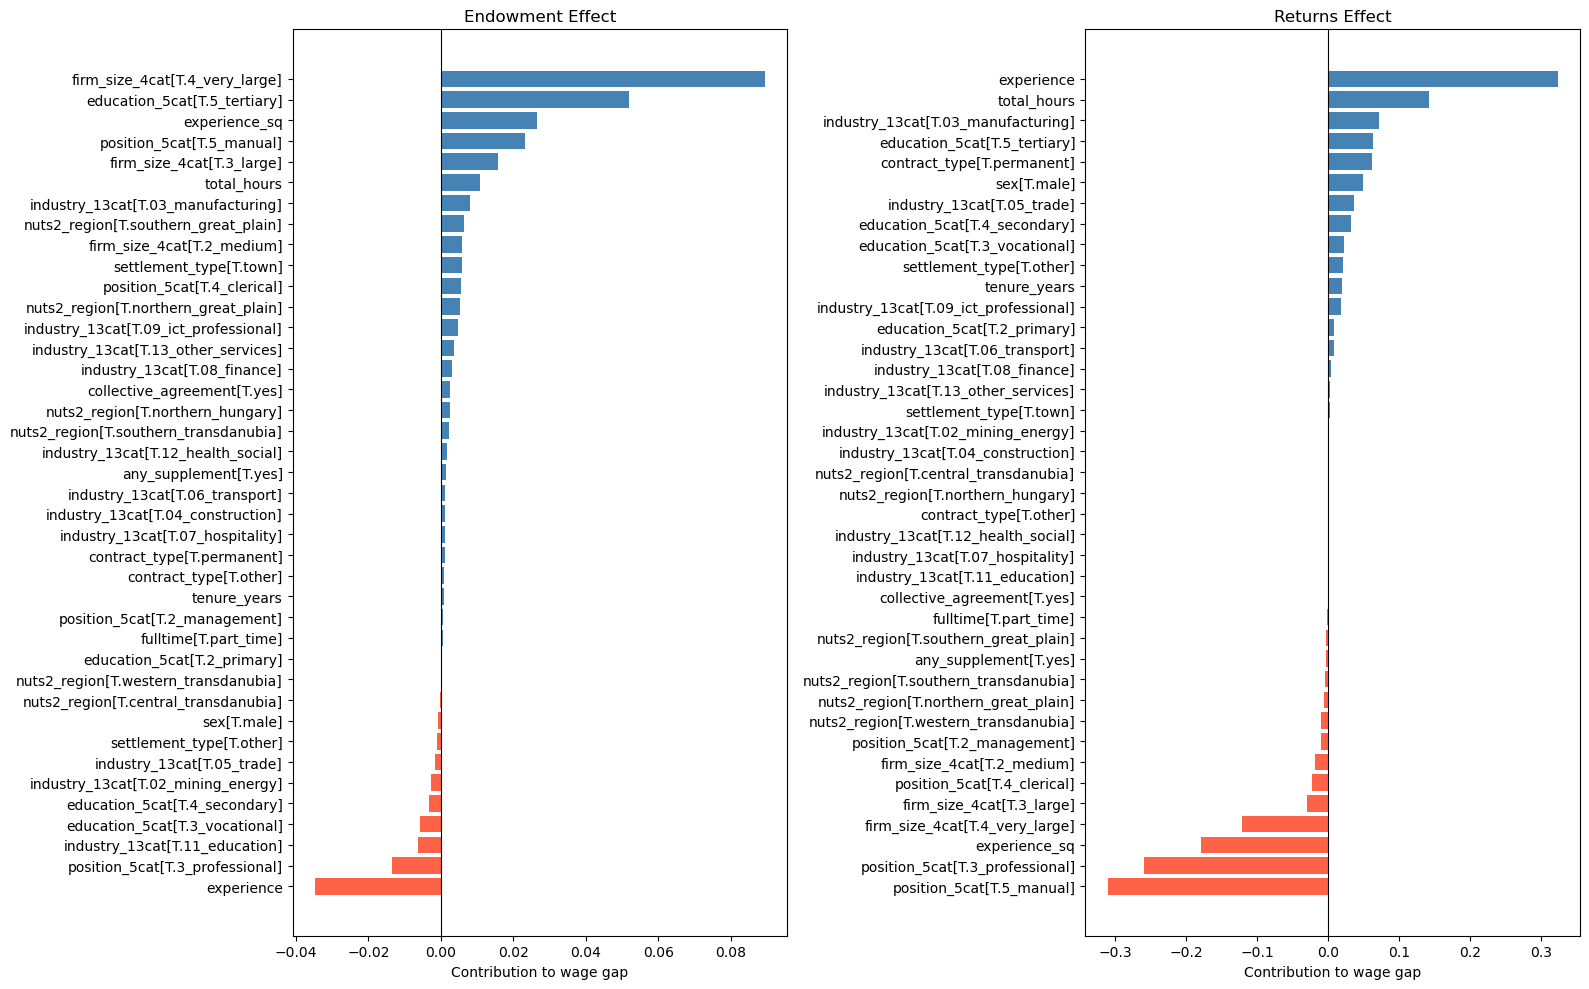

In [19]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for ax, col, title in zip(axes, ['endowment', 'returns'], ['Endowment Effect', 'Returns Effect']):
    data = decomp[col].sort_values()
    colors = ['steelblue' if v > 0 else 'tomato' for v in data]
    ax.barh(data.index, data.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Contribution to wage gap')

plt.tight_layout()
plt.savefig("../figs/BO_endowment_vs_returns.png", dpi=300, bbox_inches='tight')
plt.show()

For readability, we plot the ten largest contributors to each component separately rather than all variables at once. The left panel shows the ten variables with the largest absolute endowment effects, and the right panel the ten largest returns effects.

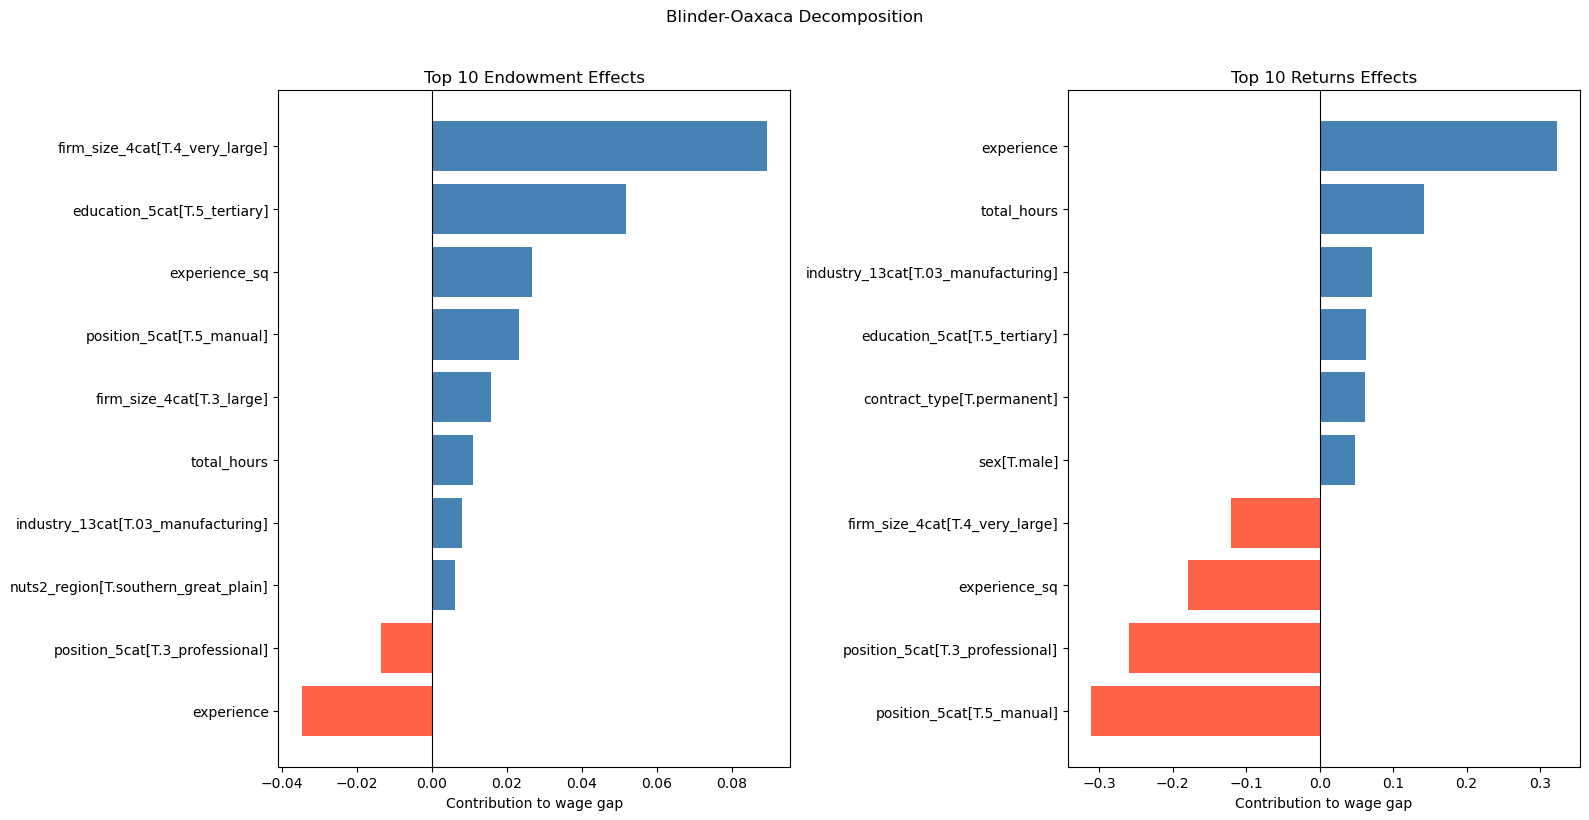

In [20]:
def plot_blinder_oaxaca(decomp, n_top=10):
    # Top n by absolute endowment effect
    top_endowment = decomp['endowment'].abs().nlargest(n_top).index
    # Top n by absolute returns effect
    top_returns = decomp['returns'].abs().nlargest(n_top).index
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Endowment plot
    plot_end = decomp.loc[top_endowment, 'endowment'].sort_values()
    colors = ['steelblue' if v > 0 else 'tomato' for v in plot_end]
    axes[0].barh(plot_end.index, plot_end.values, color=colors)
    axes[0].axvline(0, color='black', linewidth=0.8)
    axes[0].set_title('Top 10 Endowment Effects')
    axes[0].set_xlabel('Contribution to wage gap')
    
    # Returns plot
    plot_ret = decomp.loc[top_returns, 'returns'].sort_values()
    colors = ['steelblue' if v > 0 else 'tomato' for v in plot_ret]
    axes[1].barh(plot_ret.index, plot_ret.values, color=colors)
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title('Top 10 Returns Effects')
    axes[1].set_xlabel('Contribution to wage gap')
    
    plt.suptitle('Blinder-Oaxaca Decomposition', y=1.02)
    plt.tight_layout()
    plt.savefig("../figs/BO_compact_blinder_oaxaca.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_blinder_oaxaca(decomp)